In [2]:
import collections
import itertools
from copy import copy
from types import SimpleNamespace

import holoviews as hv
import kwant
import numpy as np

if tuple(int(i) for i in np.__version__.split(".")[:3]) <= (1, 8, 0):
    raise RuntimeError("numpy >= (1, 8, 0) is required")

__all__ = ["spectrum", "hamiltonian_array", "h_k", "pauli"]

pauli = SimpleNamespace(
    s0=np.array([[1.0, 0.0], [0.0, 1.0]]),
    sx=np.array([[0.0, 1.0], [1.0, 0.0]]),
    sy=np.array([[0.0, -1j], [1j, 0.0]]),
    sz=np.array([[1.0, 0.0], [0.0, -1.0]]),
)

pauli.s0s0 = np.kron(pauli.s0, pauli.s0)
pauli.s0sx = np.kron(pauli.s0, pauli.sx)
pauli.s0sy = np.kron(pauli.s0, pauli.sy)
pauli.s0sz = np.kron(pauli.s0, pauli.sz)
pauli.sxs0 = np.kron(pauli.sx, pauli.s0)
pauli.sxsx = np.kron(pauli.sx, pauli.sx)
pauli.sxsy = np.kron(pauli.sx, pauli.sy)
pauli.sxsz = np.kron(pauli.sx, pauli.sz)
pauli.sys0 = np.kron(pauli.sy, pauli.s0)
pauli.sysx = np.kron(pauli.sy, pauli.sx)
pauli.sysy = np.kron(pauli.sy, pauli.sy)
pauli.sysz = np.kron(pauli.sy, pauli.sz)
pauli.szs0 = np.kron(pauli.sz, pauli.s0)
pauli.szsx = np.kron(pauli.sz, pauli.sx)
pauli.szsy = np.kron(pauli.sz, pauli.sy)
pauli.szsz = np.kron(pauli.sz, pauli.sz)


def spectrum(
    syst,
    p=None,
    k_x=None,
    k_y=None,
    k_z=None,
    title=None,
    xdim=None,
    ydim=None,
    zdim=None,
    xticks=None,
    yticks=None,
    zticks=None,
    xlims=None,
    ylims=None,
    zlims=None,
    num_bands=None,
    return_energies=False,
):
    """Function that plots system spectrum for varying parameters or momenta.

    Parameters:
    -----------
    syst : kwant.Builder object
        The un-finalized (in)finite system.
    p : dictionary
        A container used to store Hamiltonian parameters. The parameters that
        are sequences are used as plot axes.
    k_x, k_y, k_z : floats or sequences of floats
        Real space momenta at which the Hamiltonian has to be evaluated.
        If the system dimensionality is low, extra momenta are ignored.
    title : function or str
        Function that takes p as argument and generates a string. If a string
        it's used as static title.
    xdim, ydim, zdim : holoviews.Dimension or string
        The labels of the axes. Default to best guess, and extra ones
        are ignored.
    xticks, yticks zticks : list
        Lists of axes xticks, extra ones are ignored.
    xlims, ylims, zlims : tuple
        Upper and lower plot limit of the axes. If None the upper and lower
        limits of the ticks are used. Extra ones are ignored.
    num_bands : int
        Number of bands that should be plotted, only works for 2D plots. If
        None all bands are plotted.
    return_energies : bool
        If True the function only returns the energies in an array.

    Returns:
    --------
    plot : holoviews.Path object
        Plot of varying parameter vs. spectrum.
    """
    pi_ticks = [(-np.pi, r"$-\pi$"), (0, "$0$"), (np.pi, r"$\pi$")]
    if p is None:
        p = dict()
    dimensionality = syst.symmetry.num_directions
    k = [k_x, k_y, k_z]
    k = [(np.linspace(-np.pi, np.pi, 101) if i is None else i) for i in k]
    k = [(i if j < dimensionality else 0) for (j, i) in enumerate(k)]
    k_x, k_y, k_z = k

    hamiltonians, variables = hamiltonian_array(syst, p, k_x, k_y, k_z, True)
    # Don't waste effort calculating eigenvalues if we aren't going to plot
    # anything.
    if len(variables) in (1, 2):
        energies = np.linalg.eigvalsh(hamiltonians)

    if len(variables) == 0:
        raise ValueError("A 0D plot requested")

    if return_energies:
        return energies

    elif len(variables) == 1:
        # 1D plot.
        if xdim is None:
            if variables[0][0] in "k_x k_y k_z".split():
                xdim = r"${}$".format(variables[0][0])
            else:
                xdim = variables[0][0]
        if ydim is None:
            ydim = r"$E$"

        plot = hv.Path((variables[0][1], energies), kdims=[xdim, ydim])

        ticks = {}
        if isinstance(xticks, collections.abc.Iterable):
            ticks["xticks"] = list(xticks)
        elif xticks is None:
            pass
        else:
            ticks["xticks"] = xticks

        if isinstance(yticks, collections.abc.Iterable):
            ticks["yticks"] = list(yticks)
        elif isinstance(yticks, int):
            ticks["yticks"] = yticks

        xlims = tuple(xlims) if xlims is not None else (None, None)
        ylims = tuple(ylims) if ylims is not None else (None, None)

        if callable(title):
            plot = plot.relabel(title(p))
        elif isinstance(title, str):
            plot = plot.relabel(title)

        return plot.redim.range(**{xdim: xlims, ydim: ylims}).options(path=ticks)

    elif len(variables) == 2:
        # 2D plot.
        style = {}
        if xticks is None and variables[0][0] in "k_x k_y k_z".split():
            style["xticks"] = pi_ticks
        elif xticks is not None:
            style["xticks"] = list(xticks)
        if yticks is None and variables[1][0] in "k_x k_y k_z".split():
            style["yticks"] = pi_ticks
        elif yticks is not None:
            style["yticks"] = list(yticks)

        if xdim is None:
            if variables[0][0] in "k_x k_y k_z".split():
                xdim = r"${}$".format(variables[0][0])
            else:
                xdim = variables[0][0]
        if ydim is None:
            if variables[1][0] in "k_x k_y k_z".split():
                ydim = r"${}$".format(variables[1][0])
            else:
                ydim = variables[1][0]
        if zdim is None:
            zdim = r"$E$"

        if zticks is not None:
            style["zticks"] = zticks

        if xlims is None:
            xlims = np.round([min(variables[0][1]), max(variables[0][1])], 2)
        if ylims is None:
            ylims = np.round([min(variables[1][1]), max(variables[1][1])], 2)
        if zlims is None:
            zlims = (None, None)

        kwargs = {
            "extents": (xlims[0], ylims[0], zlims[0], xlims[1], ylims[1], zlims[1]),
            "kdims": [xdim, ydim],
            "vdims": [zdim],
        }

        xs = np.linspace(*xlims, energies.shape[1])
        ys = np.linspace(*ylims, energies.shape[0])

        if num_bands is None:
            plot = hv.Overlay(
                [
                    hv.Surface((xs, ys, energies[:, :, i]), **kwargs).options(**style)
                    for i in range(energies.shape[-1])
                ]
            )
        else:
            mid = energies.shape[-1] // 2
            num_bands //= 2
            plot = hv.Overlay(
                [
                    hv.Surface((xs, ys, energies[:, :, i]), **kwargs).options(**style)
                    for i in range(mid - num_bands, mid + num_bands)
                ]
            )

        if callable(title):
            plot = plot.relabel(title(p))
        elif isinstance(title, str):
            plot = plot.relabel(title)

        return plot.options(fig_size=200)

    else:
        raise ValueError("Cannot make 4D plots yet.")


def h_k(syst, p, momentum):
    """Function that returns the Hamiltonian of a kwant 1D system as a momentum.
    """
    return hamiltonian_array(syst, p, momentum)[0]


def hamiltonian_array(syst, params=None, k_x=0, k_y=0, k_z=0, return_grid=False):
    """Evaluate the Hamiltonian of a system over a grid of parameters.

    Parameters:
    -----------
    syst : kwant.Builder object
        The un-finalized kwant system whose Hamiltonian is calculated.
    params : dictionary
        A container of Hamiltonian parameters. The parameters that are
        sequences are used to loop over.
    k_x, k_y, k_z : floats or sequences of floats
        Momenta at which the Hamiltonian has to be evaluated.  If the system
        only has 1 translation symmetry, only `k_x` is used, and interpreted as
        lattice momentum. Otherwise the momenta are in reciprocal space.
    return_grid : bool
        Whether to also return the names of the variables used for expansion,
        and their values.

    Returns:
    --------
    hamiltonians : numpy.ndarray
        An array with the Hamiltonians. The first n-2 dimensions correspond to
        the expanded variables.
    parameters : list of tuples
        Names and ranges of values that were used in evaluation of the
        Hamiltonians.

    Examples:
    ---------
    >>> hamiltonian_array(syst, dict(t=1, mu=np.linspace(-2, 2)),
    ...                   k_x=np.linspace(-np.pi, np.pi))
    >>> hamiltonian_array(sys_2d, p, np.linspace(-np.pi, np.pi),
    ...                   np.linspace(-np.pi, np.pi))

    """
    # Prevent accidental mutation of input
    params = copy(params)

    try:
        space_dimensionality = syst.symmetry.periods.shape[-1]
    except AttributeError:
        space_dimensionality = 0
    dimensionality = syst.symmetry.num_directions

    if dimensionality == 0:
        syst = syst.finalized()

        def momentum_to_lattice(k):
            return {}

    else:
        if len(syst.symmetry.periods) == 1:

            def momentum_to_lattice(k):
                if any(k[dimensionality:]):
                    raise ValueError("Dispersion is 1D, but more momenta are provided.")
                return {"k_x": k[0]}

        else:
            B = np.array(syst.symmetry.periods).T
            A = B @ np.linalg.inv(B.T @ B)

            def momentum_to_lattice(k):
                lstsq = np.linalg.lstsq(A, k[:space_dimensionality], rcond=-1)
                k, residuals = lstsq[:2]
                if np.any(abs(residuals) > 1e-7):
                    raise RuntimeError(
                        "Requested momentum doesn't correspond"
                        " to any lattice momentum."
                    )
                return dict(zip(["k_x", "k_y", "k_z"], list(k)))

        syst = kwant.wraparound.wraparound(syst).finalized()

    changing = dict()
    for key, value in params.items():
        if isinstance(value, collections.abc.Iterable):
            changing[key] = value

    for key, value in [("k_x", k_x), ("k_y", k_y), ("k_z", k_z)]:
        if key in changing:
            raise RuntimeError(
                "One of the system parameters is {}, "
                "which is reserved for momentum. "
                "Please rename it.".format(key)
            )
        if isinstance(value, collections.abc.Iterable):
            changing[key] = value


    def hamiltonian(**values):
        k = [values.pop("k_x", k_x), values.pop("k_y", k_y), values.pop("k_z", k_z)]
        params.update(values)
        k = momentum_to_lattice(k)
        system_params = {**params, **k}
        return syst.hamiltonian_submatrix(params=system_params, sparse=False)

    names, values = zip(*sorted(changing.items()))


    hamiltonians = [
        hamiltonian(**dict(zip(names, value))) for value in itertools.product(*values)
    ] if changing else [
        hamiltonian(k_x=k_x, k_y=k_y, k_z=k_z)
    ]
    size = list(hamiltonians[0].shape)

    hamiltonians = np.array(hamiltonians).reshape(
        [len(value) for value in values] + size
    )

    if return_grid:
        return hamiltonians, list(zip(names, values))
    else:
        return hamiltonians
    
hv.notebook_extension("matplotlib")

/Users/adamgodel/Library/Python/3.9/lib/python/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

/Users/adamgodel/Library/Python/3.9/lib/python/site-packages/kwant/lattice.py:746: KwantDeprecationWarning: Not specfying norbs is deprecated. Always specify norbs when creating site families.
  return Monatomic(((a, 0), (0, a)), name=name, norbs=norbs)


:HoloMap   [$\mu$]
   :Overlay
      .Surface.I  :Surface   [$k_x$,$k_y$]   ($E$)
      .Surface.II :Surface   [$k_x$,$k_y$]   ($E$)
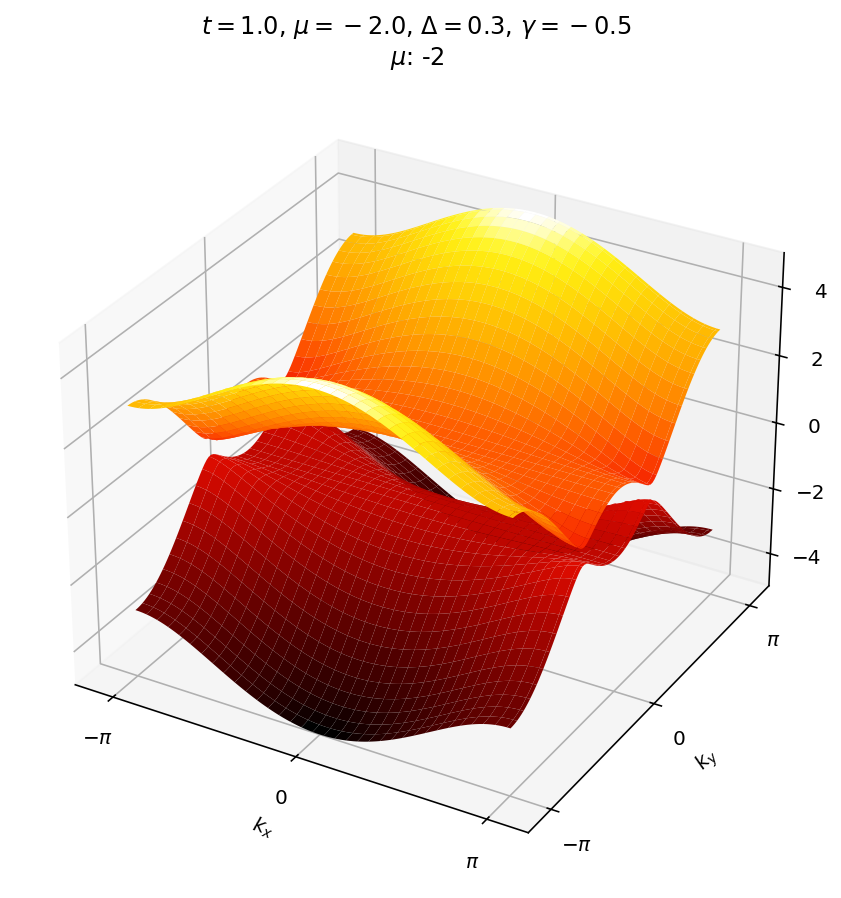
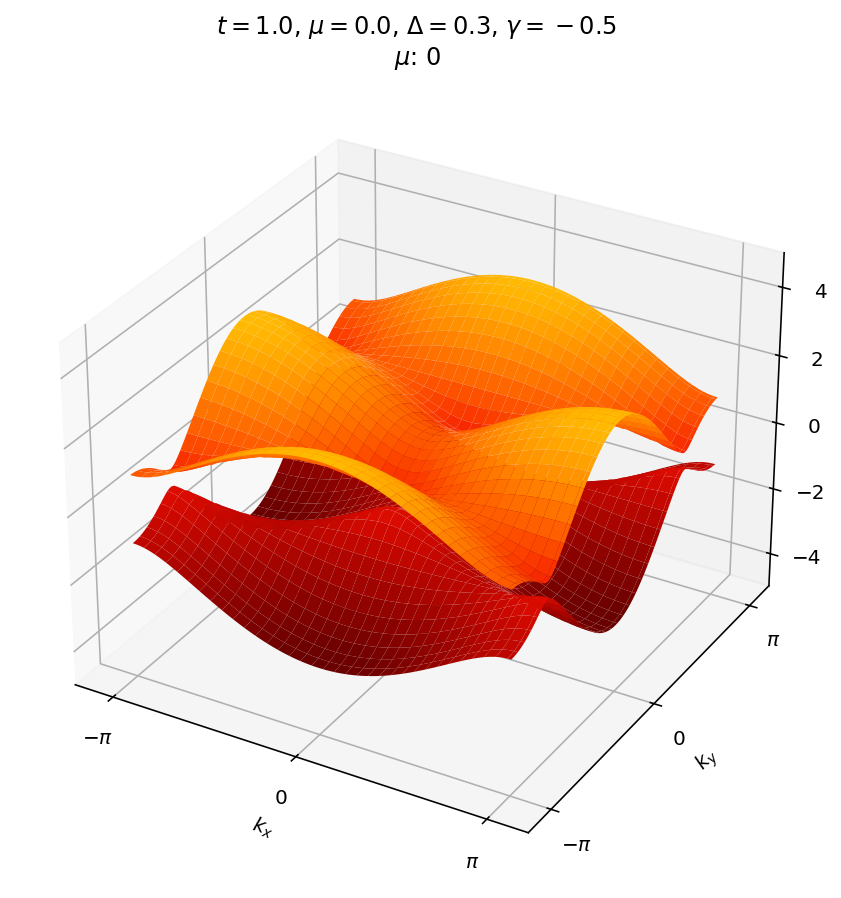
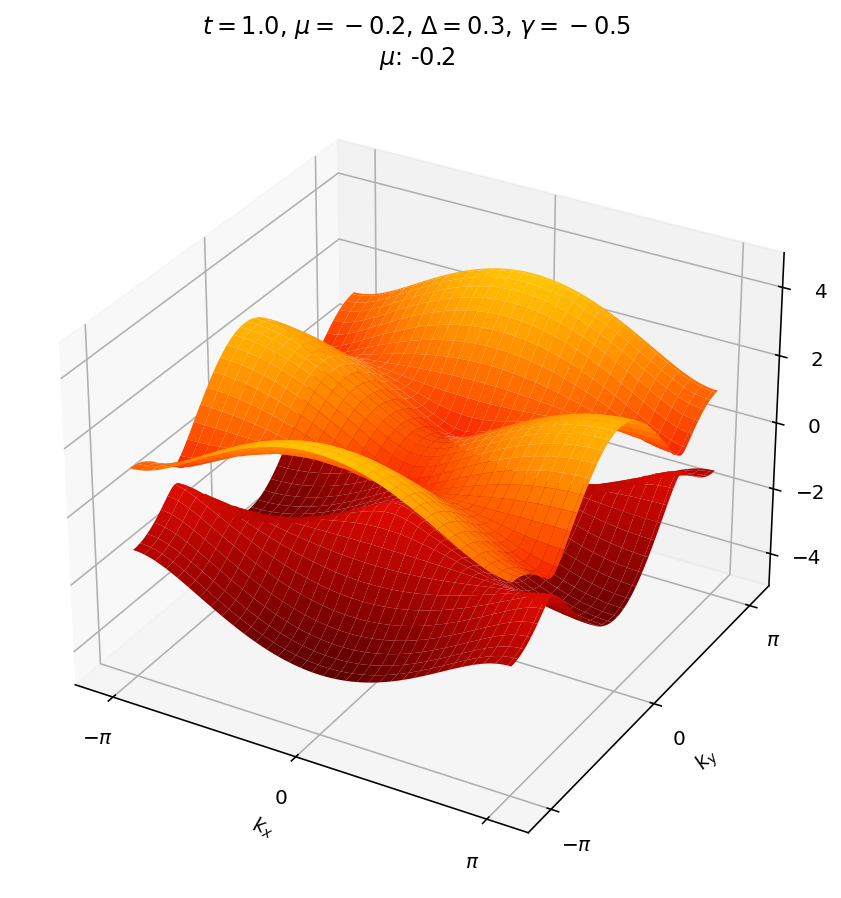
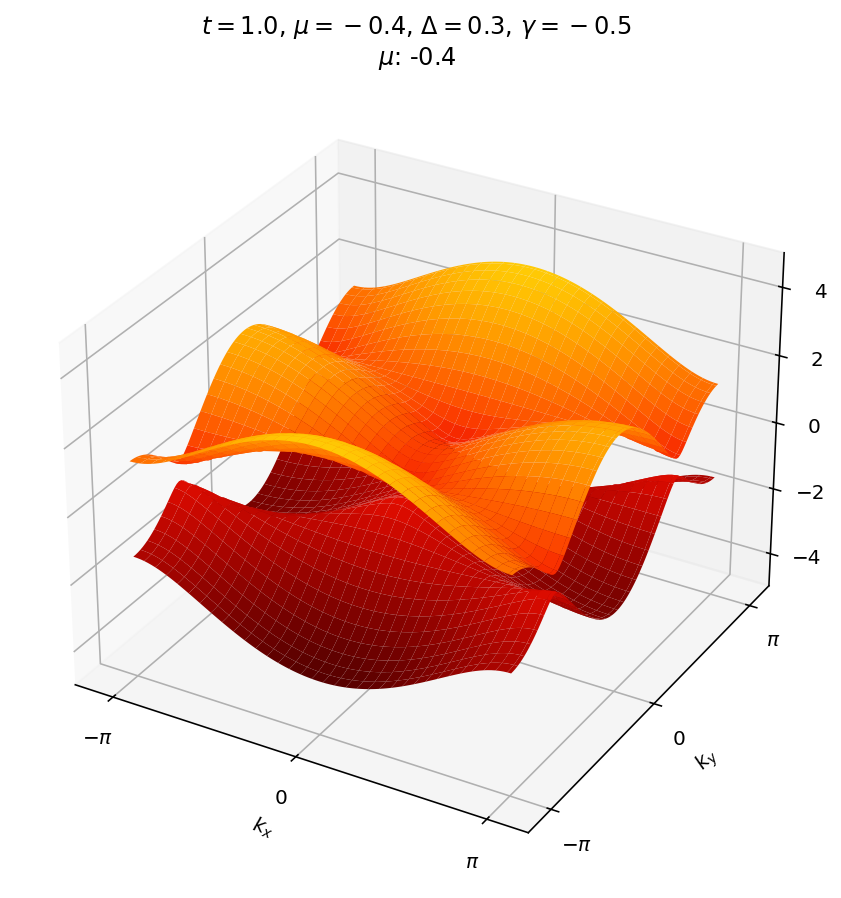
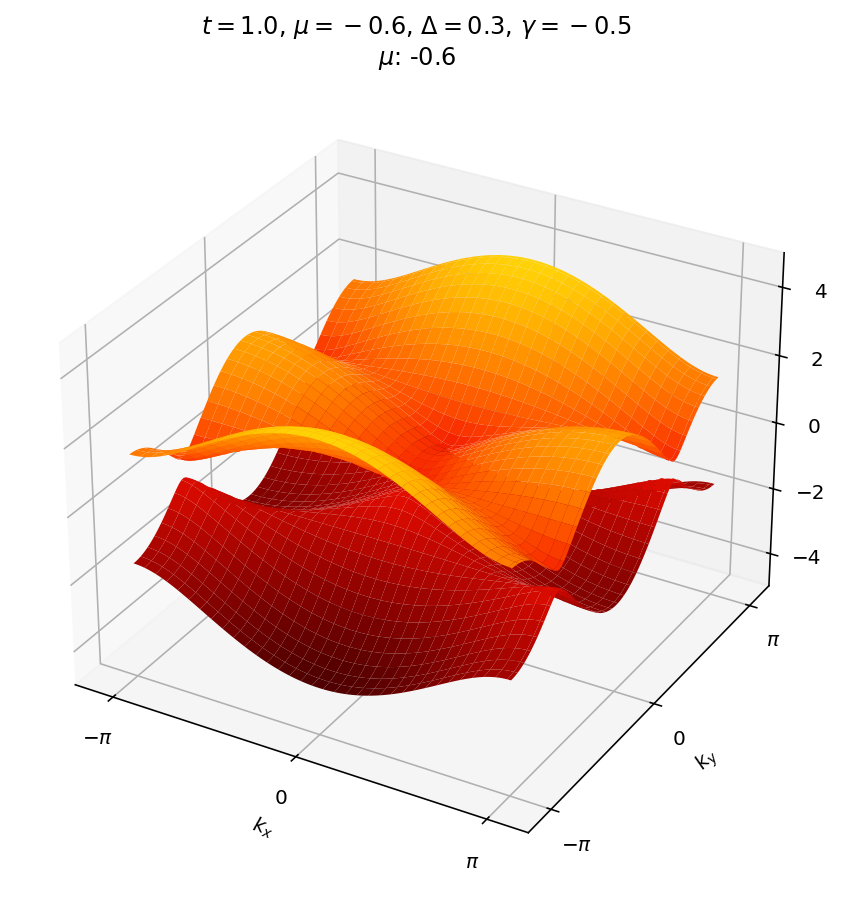
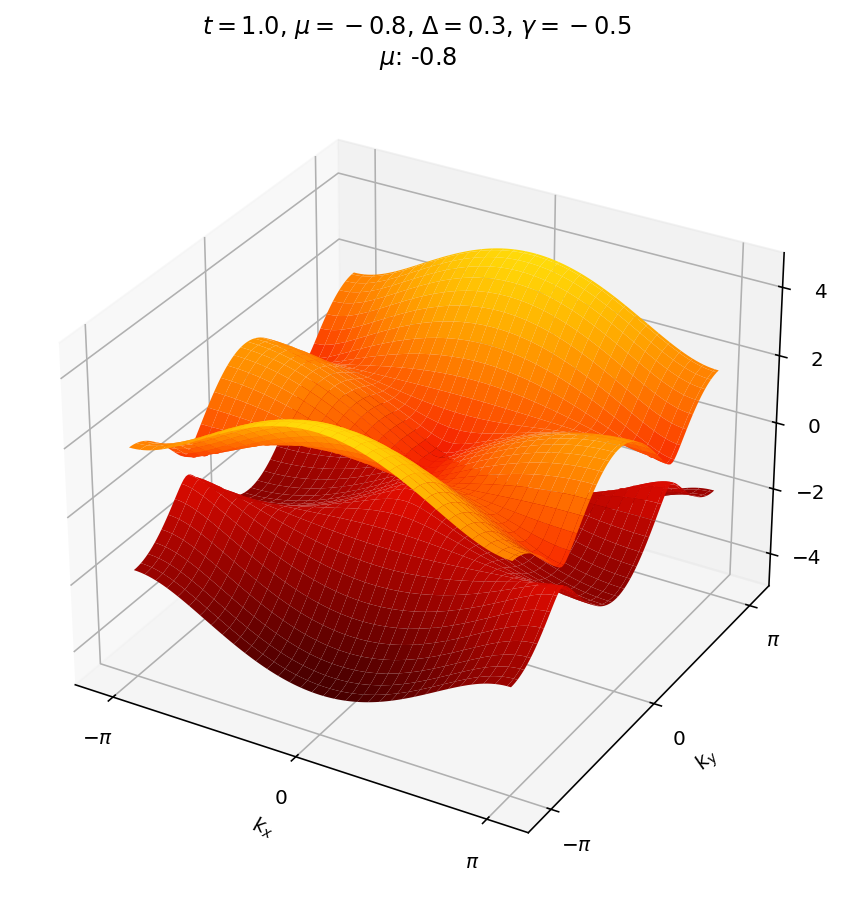
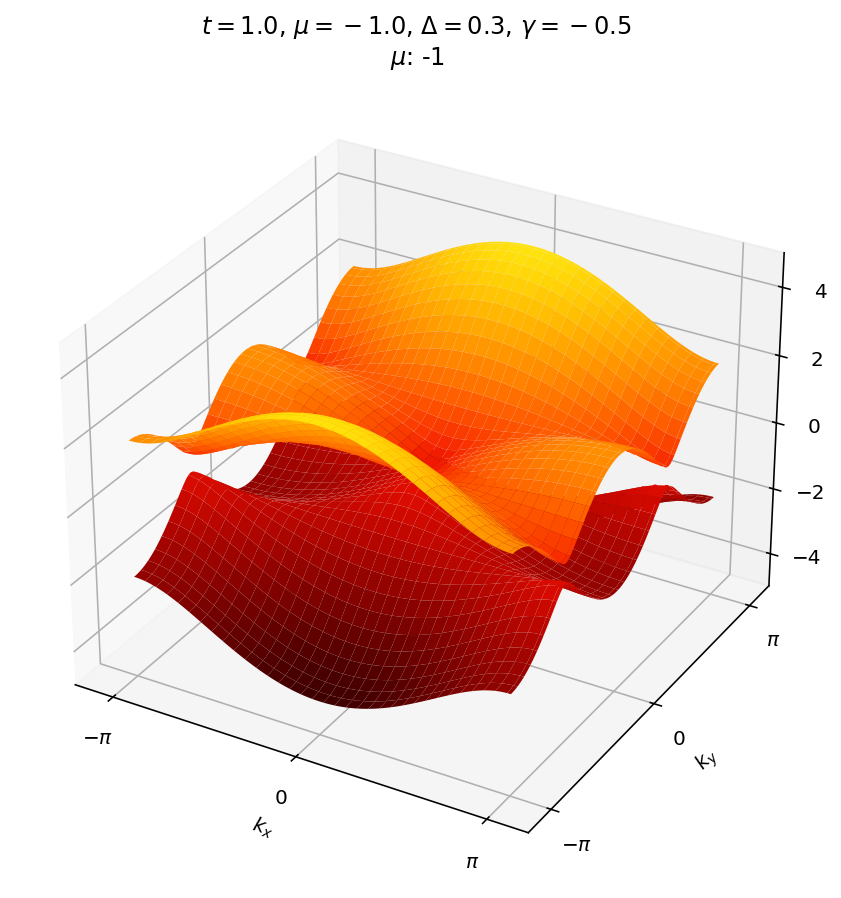
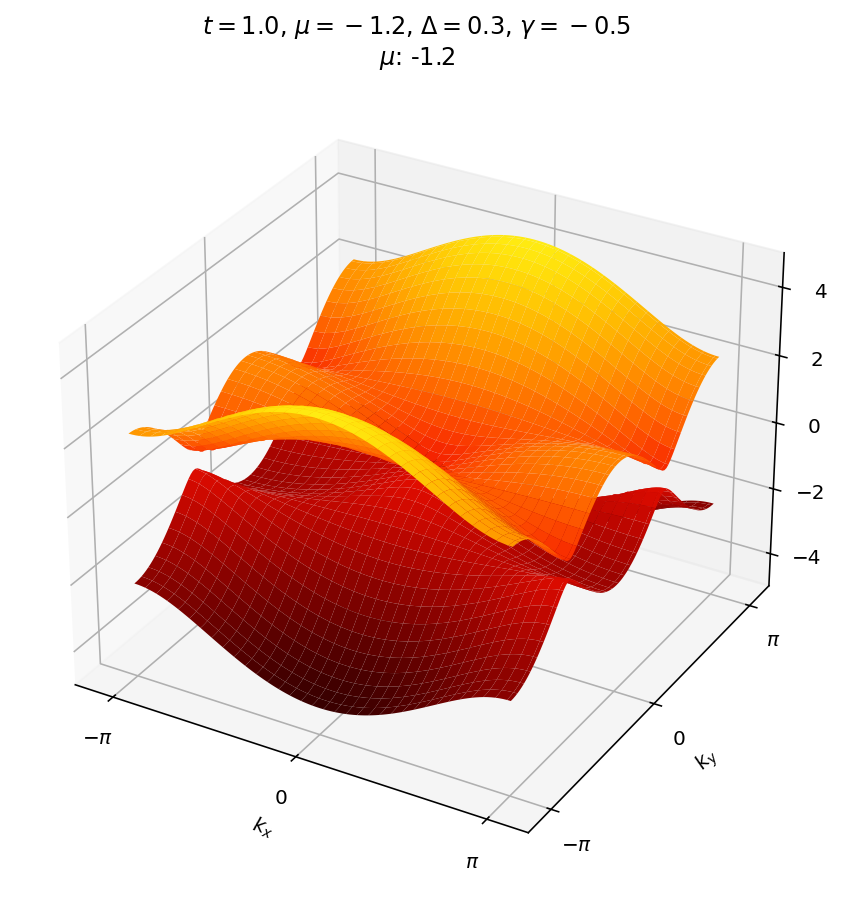
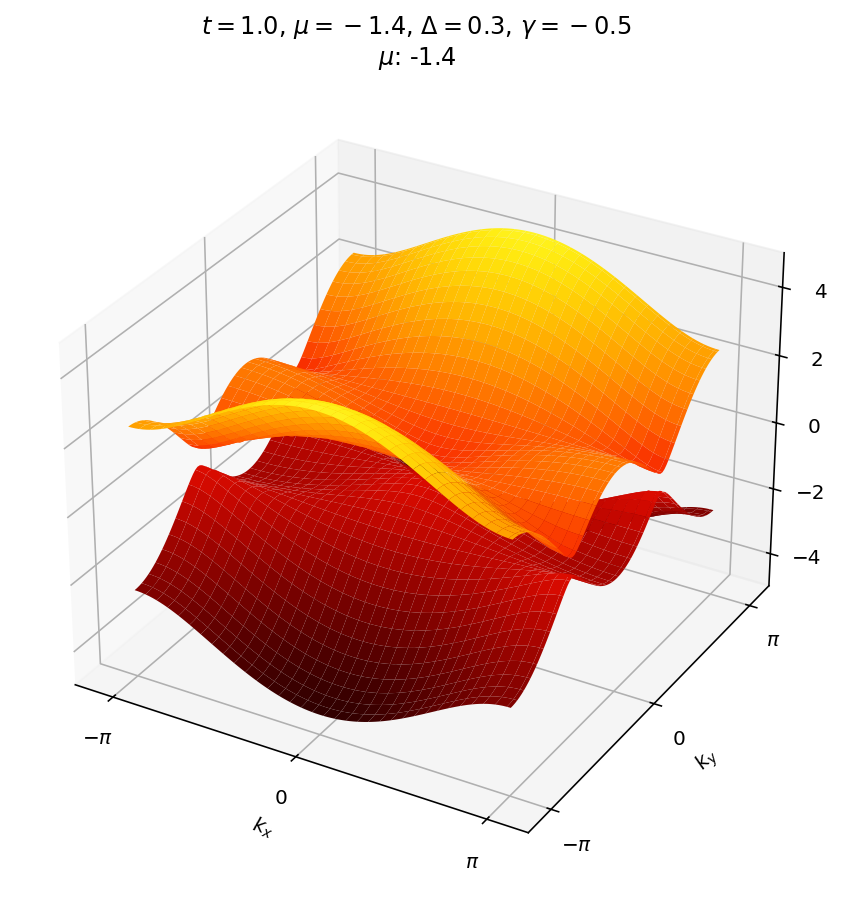
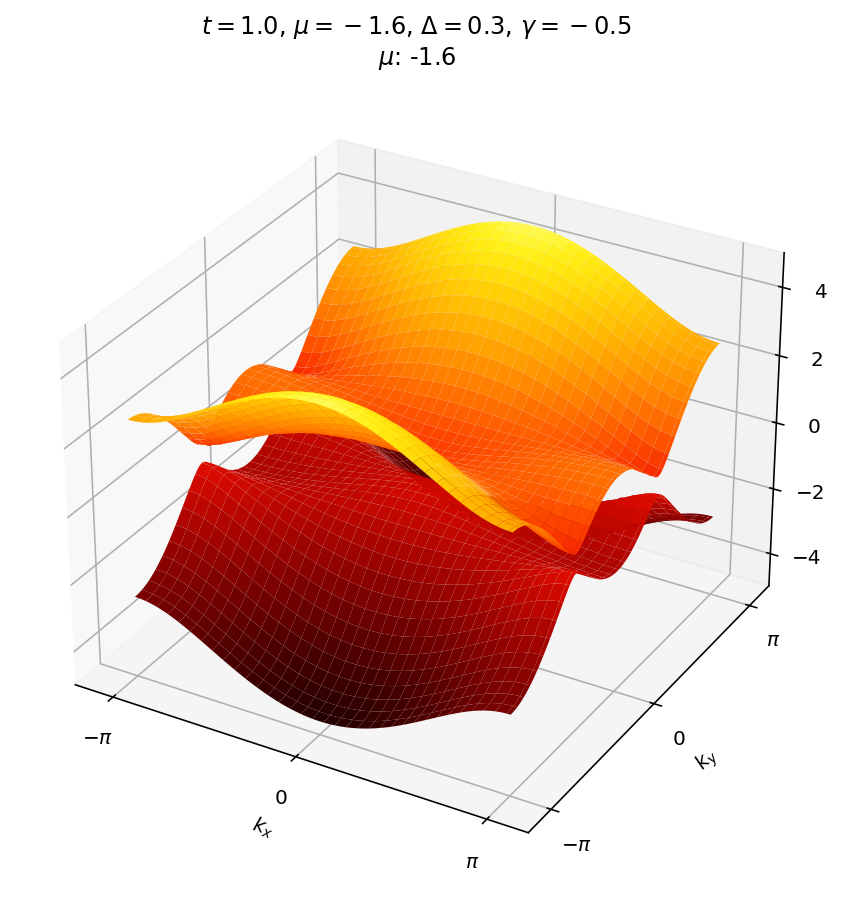
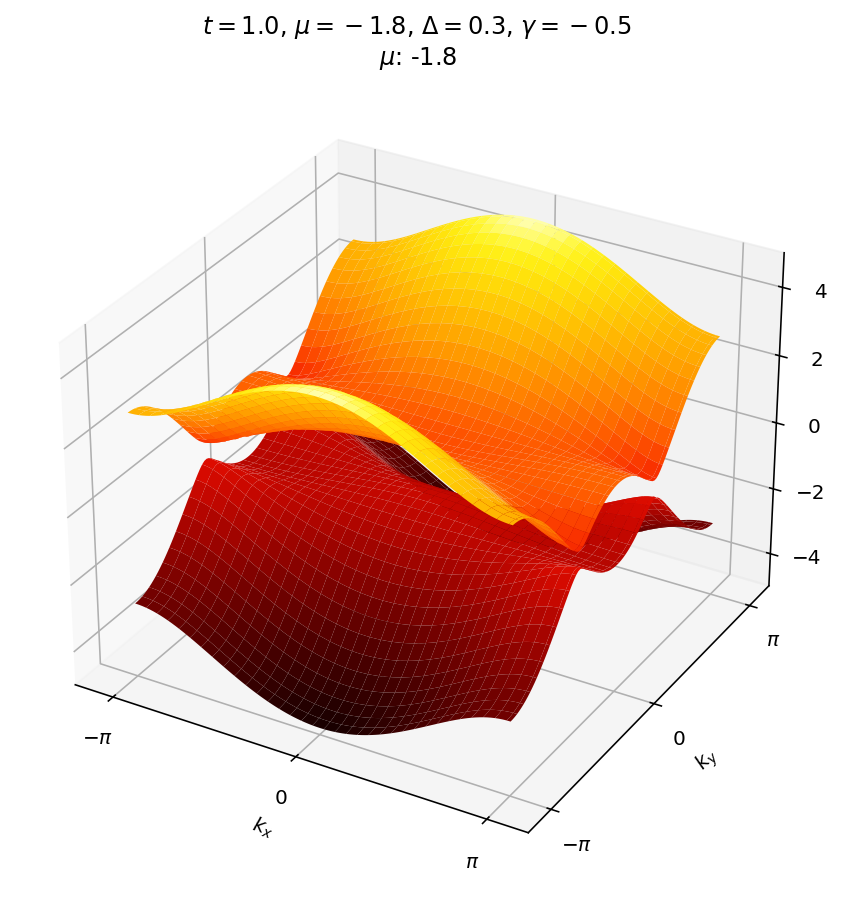
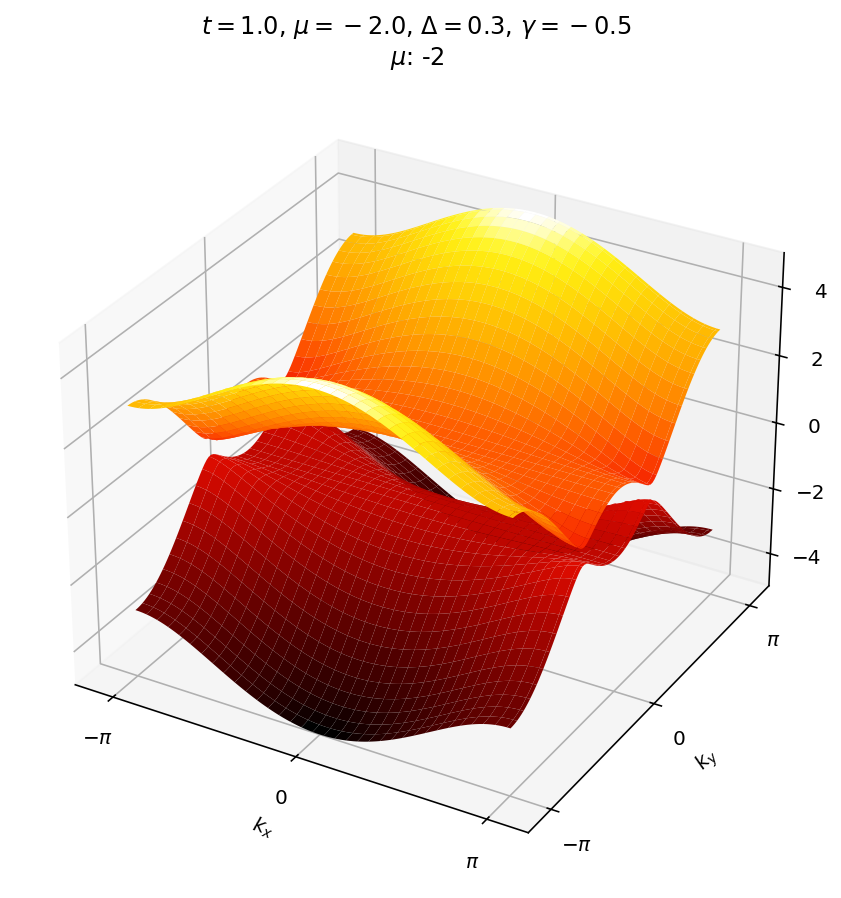

In [3]:
import numpy as np
import kwant
import holoviews

lat = kwant.lattice.square()
QWZ_infinite = kwant.Builder(kwant.TranslationalSymmetry(*lat.prim_vecs))


def onsite(site, mu):
    return -mu * pauli.sz


def hopx(site1, site2, delta, t):
    return -0.5j * delta * pauli.sy - t * pauli.sz


def hopy(site1, site2, gamma):
    return -1j * gamma * pauli.sx - gamma * pauli.sz


QWZ_infinite[lat(0, 0)] = onsite
QWZ_infinite[kwant.HoppingKind((1, 0), lat)] = hopx
QWZ_infinite[kwant.HoppingKind((0, 1), lat)] = hopy


def title(p):
    title = r"$t={:.2}$, $\mu={:.2}$, $\Delta={:.2}$, $\gamma={:.2}$"
    return title.format(p['t'], p['mu'], p['delta'], p['gamma'])


p = dict(t=1.0, delta=0.3, gamma=-0.5, mu=None)
mus = np.linspace(-2, 0, 11)
holoviews.HoloMap(
    {p["mu"]: spectrum(QWZ_infinite, p, zticks=[-4, -2, 0, 2, 4], title=title) for p["mu"] in mus},
    kdims=[r"$\mu$"],
)

/Users/adamgodel/Library/Python/3.9/lib/python/site-packages/kwant/lattice.py:120: KwantDeprecationWarning: Not specfying norbs is deprecated. Always specify norbs when creating site families.
  self.sublattices = [Monatomic(prim_vecs, offset, sname, norb)


:Overlay
   .Surface.I  :Surface   [$k_x$,$k_y$]   ($E$)
   .Surface.II :Surface   [$k_x$,$k_y$]   ($E$)
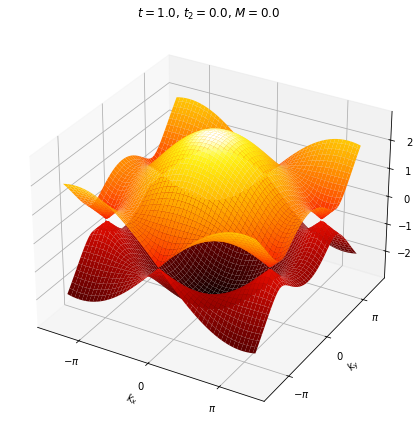

In [4]:
honeycomb = kwant.lattice.honeycomb()
a, b = honeycomb.sublattices
nnn_hoppings_a = (((-1, 0), a, a), ((0, 1), a, a), ((1, -1), a, a))
nnn_hoppings_b = (((1, 0), b, b), ((0, -1), b, b), ((-1, 1), b, b))


def title(p):
    return fr"$t={p['t']:.2}$, $t_2={p['t_2']:.2}$, $M={p['M']:.2}$"


def onsite(site, M):
    return M if site.family == a else -M


def nn_hopping(site1, site2, t):
    return t


def nnn_hopping(site1, site2, t_2):
    return 1j * t_2


haldane_infinite = kwant.Builder(kwant.TranslationalSymmetry(*honeycomb.prim_vecs))
haldane_infinite[honeycomb.shape(lambda pos: True, (0, 0))] = onsite
haldane_infinite[honeycomb.neighbors()] = nn_hopping
haldane_infinite[
    [kwant.builder.HoppingKind(*hopping) for hopping in nnn_hoppings_a]
] = nnn_hopping
haldane_infinite[
    [kwant.builder.HoppingKind(*hopping) for hopping in nnn_hoppings_b]
] = nnn_hopping

p = dict(t=1.0, t_2=0.0, M=0.0, phi=np.pi / 2)
k = (4 / 3) * np.linspace(-np.pi, np.pi, 150)
spectrum(haldane_infinite, p, k_x=k, k_y=k, title=title)